# Análisis de Redes Neuronales con Pima Indians Diabetes Dataset

En este notebook vamos a:
1. Cargar y preparar el dataset `Pima_Indians_Diabetes_Database.csv`.
2. Explicar conceptos clave: **Función de Error (Loss)**, **Optimizador (Optimizer)** y **Tasa de Aprendizaje (Learning Rate)**.
3. Entrenar diferentes arquitecturas de redes neuronales para demostrar gráficamente los conceptos de **Underfitting** (Subajuste) y **Overfitting** (Sobreajuste).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD

# Para asegurar reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

## 1. Carga y Preparación de Datos

In [9]:
# Cargar el dataset
df = pd.read_csv('dataset/Pima_Indians_Diabetes_Database.csv')

# Mostrar las primeras filas
display(df.head())

# Breve información del dataset
df.info()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [10]:
# Separar características (X) y etiqueta (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# División en datos de entrenamiento y prueba (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalización de los datos (muy importante para redes neuronales)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Conceptos Clave

### Función de Error (Loss Function)
La función de error (o pérdida) mide qué tan lejos están las predicciones de nuestra red neuronal de los valores reales. Durante el entrenamiento, el objetivo de la red es **minimizar** este error. Para problemas de clasificación binaria (como este, donde predecimos si hay diabetes o no: 1 o 0), utilizamos típicamente `binary_crossentropy`. Si el error es alto, la red se equivocó mucho; si es bajo, las predicciones son acertadas.

### Función de Optimización (Optimizer)
El optimizador es el algoritmo o método utilizado para cambiar los atributos de la red neuronal, como los pesos (weights) y el sesgo (bias), con el fin de reducir la función de error. Es decir, nos dice "en qué dirección" y "qué tanto" modificar los pesos. Ejemplos comunes son el Descenso de Gradiente Estocástico (`SGD`) o `Adam`.

### Tasa de Aprendizaje (Learning Rate)
Es un hiperparámetro crítico utilizado por el optimizador. Define el "tamaño del paso" que da el modelo en cada iteración al actualizar los pesos.
- Si el *learning rate* es **muy alto**, el modelo puede dar saltos tan grandes que nunca encuentre el mínimo error (diverge).
- Si es **muy bajo**, el modelo aprenderá muy lentamente y podría quedarse atascado.

## 3. Demostración Gráfica: Underfitting y Overfitting

- **Underfitting (Subajuste)**: Ocurre cuando el modelo es demasiado simple (pocas neuronas/capas) o se entrenó muy poco. No es capaz de aprender los patrones de los datos de entrenamiento, por lo que su error será alto tanto en entrenamiento como en validación.
- **Overfitting (Sobreajuste)**: Ocurre cuando el modelo es demasiado complejo o se entrena por demasiadas épocas. Aprende "de memoria" los datos de entrenamiento (incluso el ruido), logrando un error casi nulo en entrenamiento, pero perdiendo la capacidad de generalizar frente a datos nuevos. Se observa gráficamente cuando el error de entrenamiento sigue bajando, pero el error de validación comienza a subir.
- **Modelo Balanceado**: El modelo generaliza bien. El error de entrenamiento y validación bajan juntos hasta estabilizarse.

In [11]:
def plot_history(history, title):
    """Función para graficar la pérdida y precisión del entrenamiento y validación"""
    plt.figure(figsize=(12, 4))
    
    # Gráfica de la Pérdida (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Función de Error (Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()
    
    # Gráfica de la Precisión (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Precisión (Accuracy)')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### Caso 1: Underfitting
Creamos un modelo muy simple con unas pocas neuronas y lo entrenamos por pocas épocas con una tasa de aprendizaje pequeña.

/Users/vchibilisco/Documents/proyectos/facultad/ejemplos-IA/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


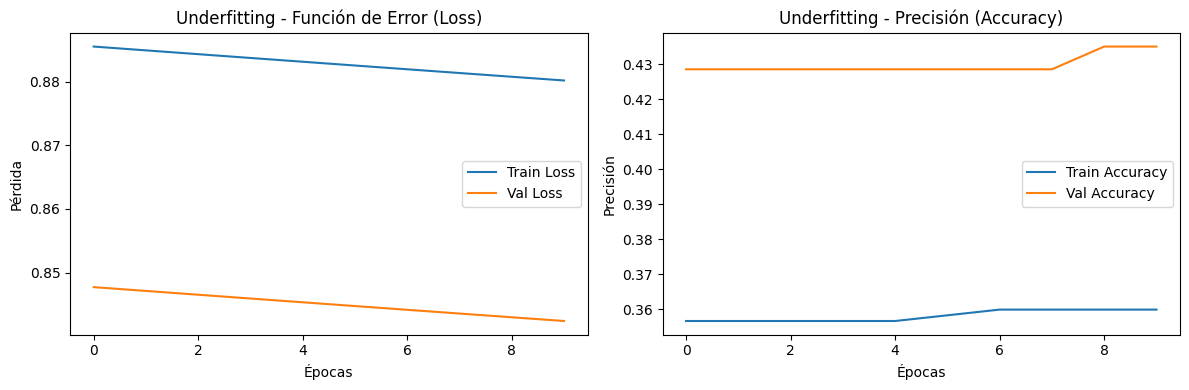

In [12]:
model_underfit = Sequential([
    Dense(4, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='sigmoid')
])

# Usamos un learning rate muy pequeño con SGD
optimizer_under = SGD(learning_rate=0.0001)

model_underfit.compile(optimizer=optimizer_under, 
                       loss='binary_crossentropy', 
                       metrics=['accuracy'])

# Entrenamos muy pocas épocas
history_underfit = model_underfit.fit(X_train_scaled, y_train, 
                                      epochs=10, 
                                      validation_data=(X_test_scaled, y_test), 
                                      verbose=0)

plot_history(history_underfit, "Underfitting")

### Caso 2: Overfitting
Creamos un modelo demasiado complejo (muchas capas y neuronas) y lo entrenamos por muchas épocas, permitiendo que "memorice" los datos de entrenamiento.

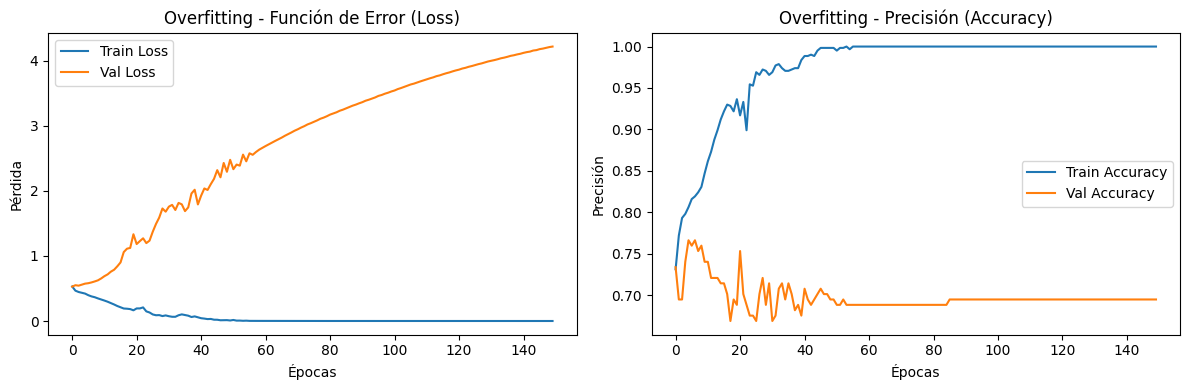

In [13]:
model_overfit = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Adam con un learning rate típico
optimizer_over = Adam(learning_rate=0.001)

model_overfit.compile(optimizer=optimizer_over, 
                      loss='binary_crossentropy', 
                      metrics=['accuracy'])

# Entrenamos por muchas épocas
history_overfit = model_overfit.fit(X_train_scaled, y_train, 
                                    epochs=150, 
                                    validation_data=(X_test_scaled, y_test), 
                                    verbose=0)

plot_history(history_overfit, "Overfitting")

### Caso 3: Modelo Balanceado (Buen Ajuste)
Creamos un modelo intermedio. Además, utilizamos un Dropout (para regularización, que ayuda a evitar el overfitting apagando aleatoriamente neuronas durante el entrenamiento).

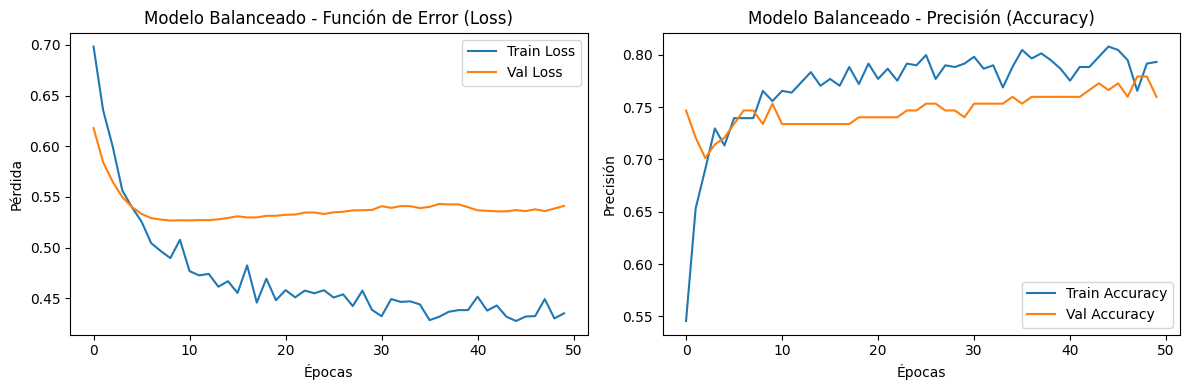

In [ ]:
model_balanced = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # Apaga el 20% de las neuronas temporalmente en cada paso para evitar memorizar
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

optimizer_bal = Adam(learning_rate=0.001)

model_balanced.compile(optimizer=optimizer_bal, 
                       loss='binary_crossentropy', 
                       metrics=['accuracy'])

# Entrenamos una cantidad razonable de épocas
history_balanced = model_balanced.fit(X_train_scaled, y_train, 
                                      epochs=50, 
                                      validation_data=(X_test_scaled, y_test), 
                                      verbose=0)

plot_history(history_balanced, "Modelo Balanceado")

### Conclusiones de las Gráficas
- En **Underfitting**, vemos que ambas curvas (Train y Validation Loss) se mantienen altas o bajan muy poco. El modelo no logra extraer patrones de los datos porque es muy simple o aprendió muy poco.
- En **Overfitting**, la curva de 'Train Loss' baja casi a cero (memoriza el conjunto de entrenamiento), pero la curva de 'Val Loss' comienza a subir después de ciertas épocas. El modelo se vuelve excelente para los datos que conoce pero malo para los nuevos.
- En el **Modelo Balanceado**, ambas curvas descienden y se estabilizan sin separarse de forma tan exagerada. El uso de técnicas como **Dropout** y un ajuste apropiado de la complejidad y épocas permiten que el modelo generalice mejor.